# Notebook Goal

The goal of this notebook is to:

- Perform an in-depth Exploratory Data Analysis (EDA) on the housing dataset.
- Visualize key trends and relationships between variables.
- Handle missing values and outliers for a cleaner dataset.
- Conduct feature engineering, including Hugging-face based feature extraction.
- Perform dimensionality reduction using PCA to optimize modeling.
- Provide meaningful business insights to guide decision-making.
- Prepare the dataset for machine learning modeling.


# **Step 1: Importing Libraries**
This code imports essential libraries for **data processing, visualization, deep learning, and machine learning** tasks.  

### **1. Data Handling**  
- **pandas** (`pd`) – Works with structured data (tables, CSVs).  
- **numpy** (`np`) – Handles numerical computations and arrays.  

### **2. Data Visualization**  
- **matplotlib.pyplot** (`plt`) – Creates graphs and charts.  
- **seaborn** (`sns`) – Enhances statistical visualizations.  

### **3. Deep Learning & NLP**  
- **torch** – Used for deep learning.  
- **tqdm** – Displays progress bars in loops.  
- **transformers** (`AutoTokenizer`, `AutoModel`) – Handles NLP tasks like text tokenization and model loading.  

### **4. Machine Learning**  
- **PCA** – Reduces dataset dimensions.  
- **OneHotEncoder** – Converts categorical data into numerical format.  



In [1]:
# %% Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from tqdm import tqdm
from transformers import AutoTokenizer, AutoModel
from sklearn.decomposition import PCA
from sklearn.preprocessing import OneHotEncoder, StandardScaler


# 🔹 Step 2: Dataset Overview

## Importance

Before analysis, I examine the dataset's structure to understand:
- The number of rows and columns.
- The data types of each column.
- Any missing values.


In [2]:

# Load the dataset
df = pd.read_csv(r"C:\Users\ahmar\OneDrive\Desktop\Task 3 Enliven AI\funda_housing_dataset/housing_data.csv")
# Display dataset information
display(df.info())
display(df.head())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211617 entries, 0 to 211616
Data columns (total 17 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   globalId               211617 non-null  int64  
 1   publicatieDatum        211617 non-null  object 
 2   postcode               211617 non-null  object 
 3   koopPrijs              210876 non-null  float64
 4   volledigeOmschrijving  211617 non-null  object 
 5   soortWoning            211617 non-null  object 
 6   categorieObject        211617 non-null  object 
 7   bouwjaar               211617 non-null  object 
 8   indTuin                211617 non-null  int64  
 9   perceelOppervlakte     144376 non-null  float64
 10  kantoor_naam_MD5hash   211617 non-null  object 
 11  aantalKamers           211617 non-null  int64  
 12  aantalBadkamers        150469 non-null  float64
 13  energielabelKlasse     88862 non-null   object 
 14  globalId.1             211617 non-nu

None

,globalId,publicatieDatum,postcode,koopPrijs,volledigeOmschrijving,soortWoning,categorieObject,bouwjaar,indTuin,perceelOppervlakte,kantoor_naam_MD5hash,aantalKamers,aantalBadkamers,energielabelKlasse,globalId.1,oppervlakte,datum_ondertekening
0,4388064,2018-07-31,1774PG,139000.0,"Ruimte, vrijheid, en altijd het water en de we...",<{woonboot}> <{vrijstaande woning}>,<{Woonhuis}>,1971-1980,1,NaN,09F114F5C5EC061F6230349892132149,3,NaN,NaN,4388064,62,2018-11-12
1,4388200,2018-09-24,7481LK,209000.0,Verrassend ruime tussenwoning nabij het centru...,<{eengezinswoning}> <{tussenwoning}>,<{Woonhuis}>,1980,1,148.0,6A91BF7DB06A8DF2C9A89064F28571E7,5,1.0,B,4388200,136,2018-08-30
2,4399344,2018-08-02,1068MS,267500.0,- ENGLISH TRANSLATION - \n\nOn the 21st of Sep...,<{tussenverdieping}> (<{appartement}>),<{Appartement}>,2001-2010,0,NaN,E983FEDC63D87BF61AE952D181C8FD17,3,NaN,NaN,4399344,70,2018-11-23
3,4400638,2018-08-04,5628EN,349000.0,Wonen in een zeer royaal bemeten geschakelde 2...,<{eengezinswoning}> <{geschakelde 2-onder-1-ka...,<{Woonhuis}>,1973,1,244.0,02BC26608B8B1A0888D3612AC7A5DB5C,5,NaN,NaN,4400638,144,2018-12-14
4,4401765,2018-08-05,7731TV,495000.0,Landgoed Junne is een eeuwenoud landgoed en li...,<{woonboerderij}> <{vrijstaande woning}>,<{Woonhuis}>,1900,0,4500.0,F56B2705CE24B8D78A68481ED1B276CB,8,1.0,NaN,4401765,323,2018-12-06


In [3]:
# Checking and calculating how much values null
df.isnull().sum()


globalId                      0
publicatieDatum               0
postcode                      0
koopPrijs                   741
volledigeOmschrijving         0
soortWoning                   0
categorieObject               0
bouwjaar                      0
indTuin                       0
perceelOppervlakte        67241
kantoor_naam_MD5hash          0
aantalKamers                  0
aantalBadkamers           61148
energielabelKlasse       122755
globalId.1                    0
oppervlakte                   0
datum_ondertekening           0
dtype: int64

# ✅ **Key Observations**:
# - The dataset contains **211,000+ rows** and multiple features.
# - There are **categorical, numerical, and date-based columns**.
# - Some **missing values** exist in critical features like `price`,`energy_label`,`num_bathrooms`,`plot_area`.

# 🔹 Step 3: Remove cloning of features

## Importance

Before analysis, I examine the dataset's have two features with same values:
- Checking by printing first five values of globalID.1 and globalID
- After for ensuring, use condition to check all values


In [4]:
df["globalId.1"].head(5)

0    4388064
1    4388200
2    4399344
3    4400638
4    4401765
Name: globalId.1, dtype: int64

In [5]:
df["globalId"].head(5)

0    4388064
1    4388200
2    4399344
3    4400638
4    4401765
Name: globalId, dtype: int64

In [6]:
# Here, Check all entries of the globalID and globalID.1 are same
if (df["globalId"] == df["globalId.1"]).all():
    print("All entries in both columns are the same.")
else:
    print("There are differences between the columns.")

All entries in both columns are the same.


In [7]:
#drop out the column
df.drop(columns=['globalId.1'], inplace=True)


# ✅ **Key Observations**:
# - The dataset contains **globalID** and **globalID.1** features with same values.
# - Then remove the feature globalID.1 to remove clonning.



# 🔹 Step 4: Renaming Columns for Better Clarity

## Importance

The dataset contains Dutch column names, making it difficult to interpret. We rename them for clarity and consistency.


In [8]:
#Rename the features of the dataset
df.rename(columns={
    "globalId": "id", "publicatieDatum": "publication_date", "postcode": "postal_code", "koopPrijs": "price",
    "volledigeOmschrijving": "description", "soortWoning": "property_type", "categorieObject": "category",
    "bouwjaar": "year_built", "indTuin": "garden", "perceelOppervlakte": "plot_area",
    "kantoor_naam_MD5hash": "agency_hash", "aantalKamers": "num_rooms", "aantalBadkamers": "num_bathrooms",
    "energielabelKlasse": "energy_label", "globalId.1": "global_id_1", "oppervlakte": "surface_area",
    "datum_ondertekening": "signing_date"
}, inplace=True)


Key Observations
Column names are now intuitive and readable.


# 🔹 Step 5: Handling Missing Values


## Importance

Missing values can bias the analysis and affect model performance. We:

- Drop rows where the price (target variable) is missing.
- Fill numerical columns with the median to prevent skewing the data.
- Fill categorical columns with the mode (most frequent value).


In [9]:
df.dropna(subset=["price"], inplace=True)
df[['num_bathrooms', 'plot_area', 'price']] = df[['num_bathrooms', 'plot_area', 'price']].fillna(df[['num_bathrooms', 'plot_area', 'price']].median())


# ✅ **Results**:
# - All rows missing **price** are removed.
# - Other missing values are **imputed** with median.
# - Dataset is now **cleaner and ready for analysis**.


# 🔹 **Summary Statistics**


In [10]:
df.shape

(210876, 16)

In [11]:
df.describe()


,id,price,garden,plot_area,num_rooms,num_bathrooms,surface_area
count,2.108760e+05,2.108760e+05,210876.000000,210876.000000,210876.000000,210876.000000,210876.000000
mean,4.313006e+06,3.213849e+05,0.707937,436.473273,4.654351,1.078700,119.958834
std,1.658178e+05,2.028539e+05,0.454712,2066.806346,1.578605,0.296959,49.275980
min,2.567727e+06,2.150000e+02,0.000000,10.000000,1.000000,1.000000,1.000000
25%,4.173284e+06,2.000000e+05,0.000000,164.000000,4.000000,1.000000,90.000000
50%,4.269214e+06,2.750000e+05,1.000000,208.000000,5.000000,1.000000,115.000000
75%,4.458436e+06,3.750000e+05,1.000000,265.000000,5.000000,1.000000,139.000000
max,4.613566e+06,9.950000e+06,1.000000,297500.000000,41.000000,8.000000,3210.000000


# ✅ **Key Observations**:
# - **Right-skewed distributions** in `price`, `plot_area`, and `num_rooms`.
# - Some extreme **outliers** in `surface_area`.

# 🔎 Visualizing Missing Values

To understand the pattern of missing values, we use a heatmap.


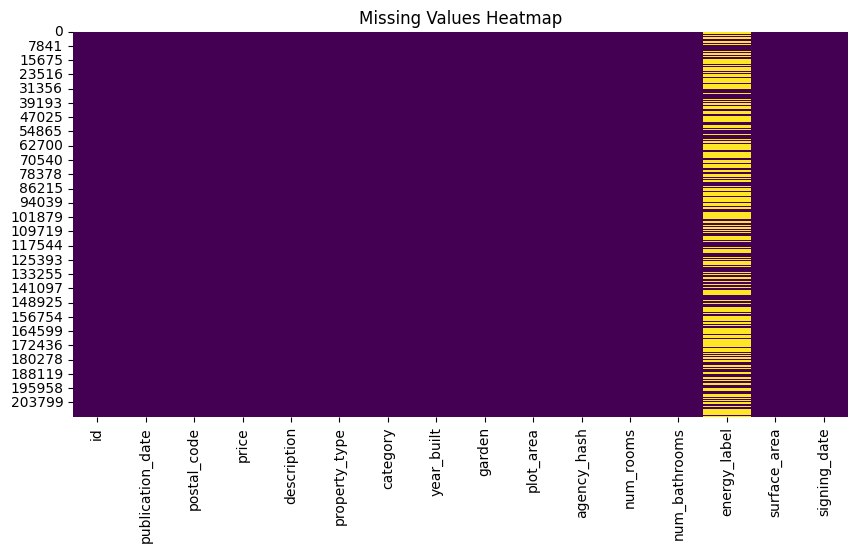

In [12]:
plt.figure(figsize=(10, 5))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.title("Missing Values Heatmap")
plt.show()


### Key Observations:
- Some columns have missing values that were filled using appropriate methods.
- Some columns will be dropped due to a high number of null values.


# 🔹 Step 6: Exploratory Data Analysis (EDA)

## Importance

Understanding data distribution is crucial for detecting patterns and anomalies.


1. **Summary Statistics**


In [13]:
display(df.describe())

,id,price,garden,plot_area,num_rooms,num_bathrooms,surface_area
count,2.108760e+05,2.108760e+05,210876.000000,210876.000000,210876.000000,210876.000000,210876.000000
mean,4.313006e+06,3.213849e+05,0.707937,436.473273,4.654351,1.078700,119.958834
std,1.658178e+05,2.028539e+05,0.454712,2066.806346,1.578605,0.296959,49.275980
min,2.567727e+06,2.150000e+02,0.000000,10.000000,1.000000,1.000000,1.000000
25%,4.173284e+06,2.000000e+05,0.000000,164.000000,4.000000,1.000000,90.000000
50%,4.269214e+06,2.750000e+05,1.000000,208.000000,5.000000,1.000000,115.000000
75%,4.458436e+06,3.750000e+05,1.000000,265.000000,5.000000,1.000000,139.000000
max,4.613566e+06,9.950000e+06,1.000000,297500.000000,41.000000,8.000000,3210.000000


# 📌 **Extracting Median Year from `year_built` Column**
# The `year_built` column contains **ranges (e.g., "1950-1960")** or single values.
# We need to extract the **median year** to represent each property consistently.


# 🔎 **Visualizing Feature Correlation**

# 🔹 Objective
To understand the feature correlation, we use a heatmap.


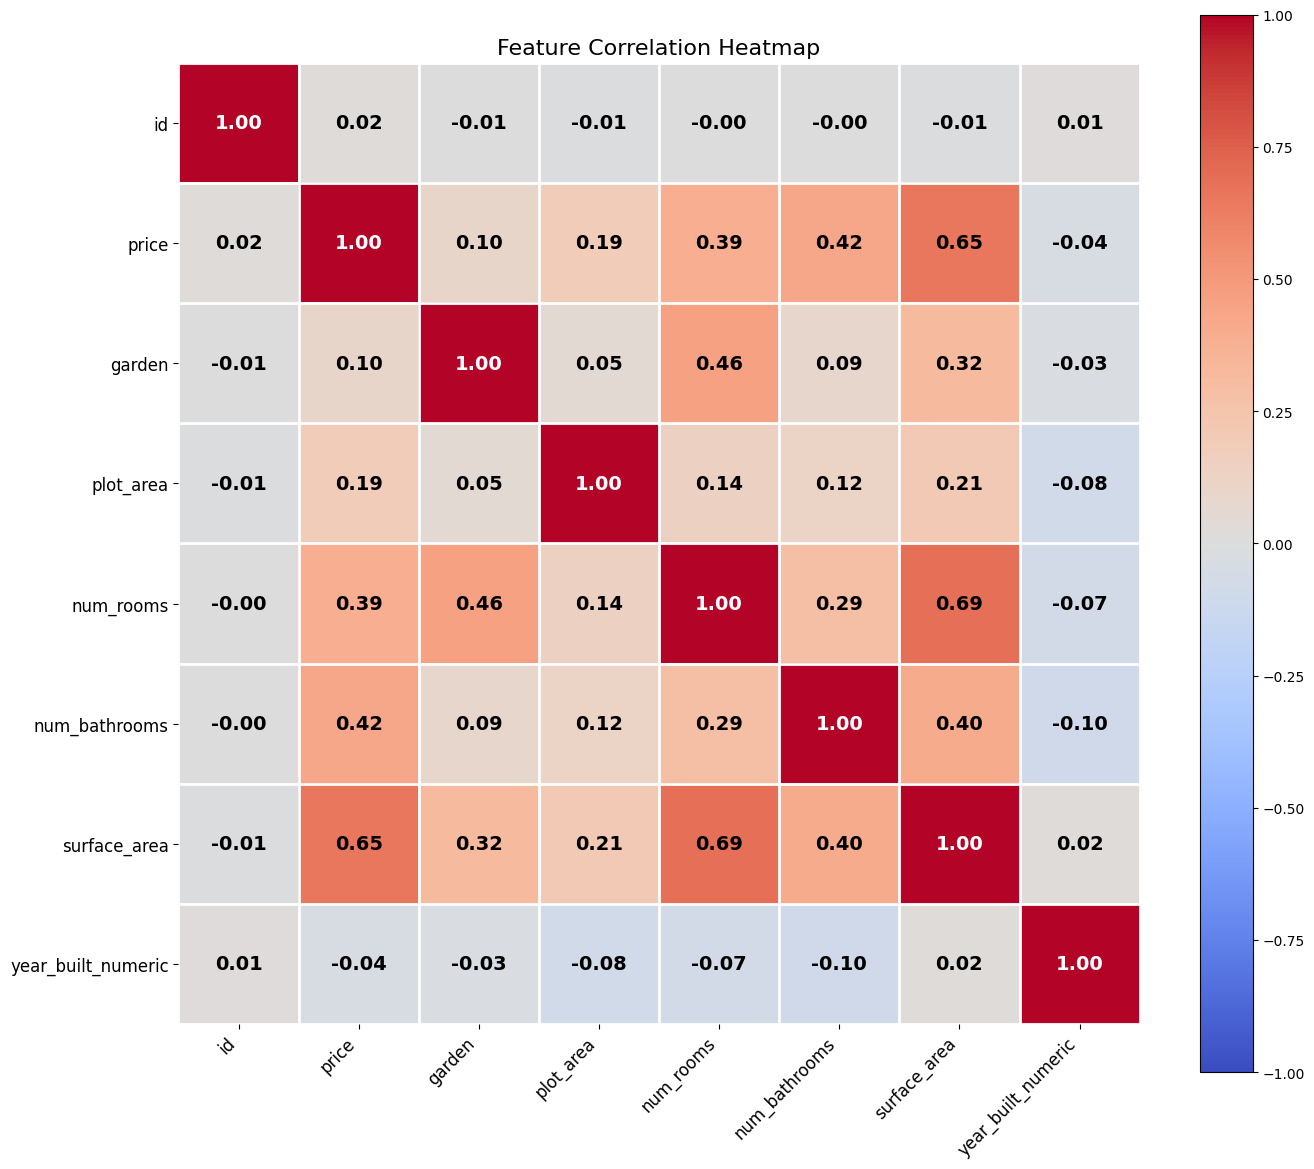

In [15]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import re

# Function to extract years from string values
def extract_years(year_str):
    try:
        numbers = re.findall(r'\d{4}', str(year_str))
        if numbers:
            return sum(int(year) for year in numbers) / len(numbers)
        else:
            return np.nan
    except:
        return np.nan

def create_missing_value_heatmap(df):
    # Process year_built column if it exists
    if 'year_built' in df.columns:
        df['year_built_numeric'] = df['year_built'].apply(extract_years)
    
    # Get all numeric columns
    numeric_df = df.select_dtypes(include=[np.number])
    
    # Remove any columns with all NaN values
    df_numeric = numeric_df.dropna(axis=1, how='all')
    
    # Compute correlation matrix, ignoring NaN values
    corr_matrix = df_numeric.corr(method='pearson', numeric_only=True)
    
    # Create figure and axes
    fig, ax = plt.subplots(figsize=(14, 12))
    
    # Create heatmap using imshow
    im = ax.imshow(corr_matrix.values, cmap='coolwarm', vmin=-1, vmax=1)
    
    # Add colorbar
    fig.colorbar(im)
    
    # Set up ticks for grid
    ax.set_xticks(np.arange(len(corr_matrix.columns)))
    ax.set_yticks(np.arange(len(corr_matrix.index)))
    
    # Label axes
    ax.set_xticklabels(corr_matrix.columns, rotation=45, ha='right', fontsize=12)
    ax.set_yticklabels(corr_matrix.index, fontsize=12)
    
    # Add text annotations with dynamic coloring
    for i in range(len(corr_matrix.index)):
        for j in range(len(corr_matrix.columns)):
            value = corr_matrix.iloc[i, j]
            text_color = 'white' if abs(value) > 0.7 else 'black'
            ax.text(j, i, f"{value:.2f}", ha='center', va='center', 
                    color=text_color, fontweight='bold', fontsize=14)
    
    # Add title
    ax.set_title("Feature Correlation Heatmap", fontsize=16)
    
    # Turn spines off for cleaner look
    for edge, spine in ax.spines.items():
        spine.set_visible(False)
    
    # Draw grid lines
    ax.set_xticks(np.arange(-.5, len(corr_matrix.columns), 1), minor=True)
    ax.set_yticks(np.arange(-.5, len(corr_matrix.index), 1), minor=True)
    ax.grid(which="minor", color="white", linestyle='-', linewidth=2)
    ax.tick_params(which="minor", bottom=False, left=False)
    
    plt.tight_layout()
    plt.savefig('correlation_matrix.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    return corr_matrix

# Example usage:
corr_matrix = create_missing_value_heatmap(df)

# ✅ **Key Observations:**
# - **Surface Area** and **Price** show a strong correlation.
# - **Year Built** has a moderate correlation with **Price**.

# 3. **Distribution of key numerical features**

# 🔹 Objective


The objective of this code is to visualize the distribution of numerical features in the dataset using histograms with KDE (Kernel Density Estimation) overlays. This helps in understanding the data's spread, skewness, and potential outliers.


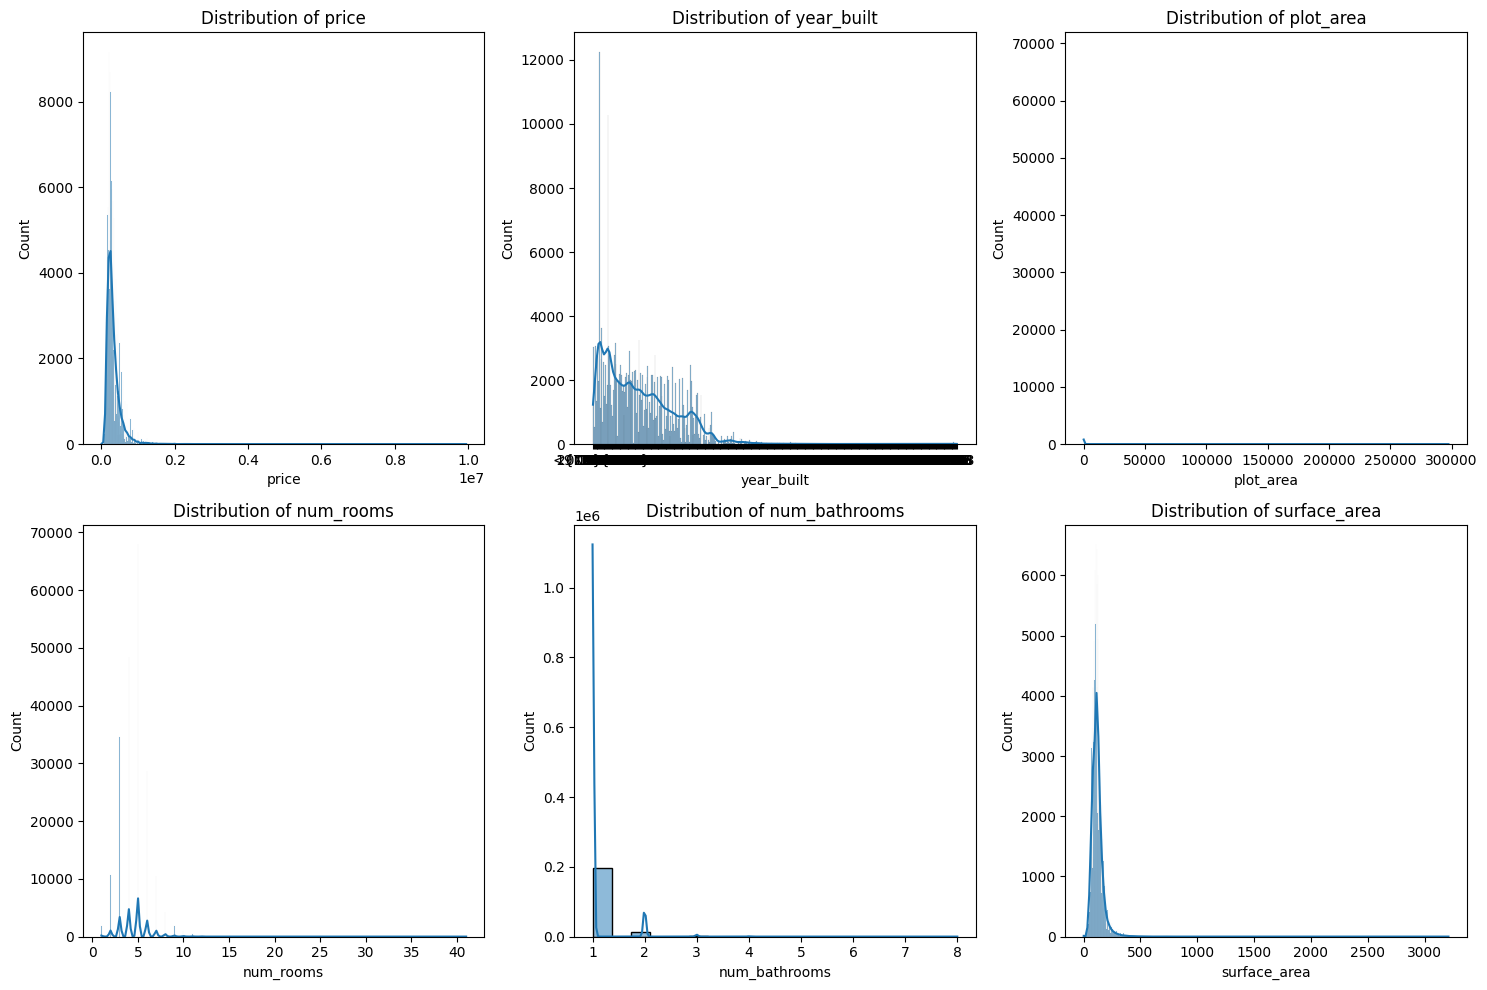

In [16]:
num_cols = ["price", "year_built", "plot_area", "num_rooms", "num_bathrooms", "surface_area"]
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(f"Distribution of {col}")

plt.tight_layout()
plt.show()


# ✅ **Key Observations:**
- **Price** distribution appears right-skewed, indicating a few high-value properties.
- **Year Built** shows a concentration of properties built in recent years, suggesting newer developments dominate the dataset.
- **Plot Area** and **Surface Area** exhibit skewness, with a few properties having significantly larger sizes.
- **Number of Rooms** and **Number of Bathrooms** follow a discrete distribution, with most properties having a standard count.
- **Outliers** may be present in **Price, Plot Area, and Surface Area**, requiring further investigation.
- **Scaling or transformation** might be needed for highly skewed features before applying machine learning models.


# 4. **Outlier Detection using Box Plots**
# 🎯 Objective:  
The goal of this visualization is to analyze the **distribution and presence of outliers** in numerical features using box plots. Box plots help in detecting skewness, spread, and extreme values in the dataset.


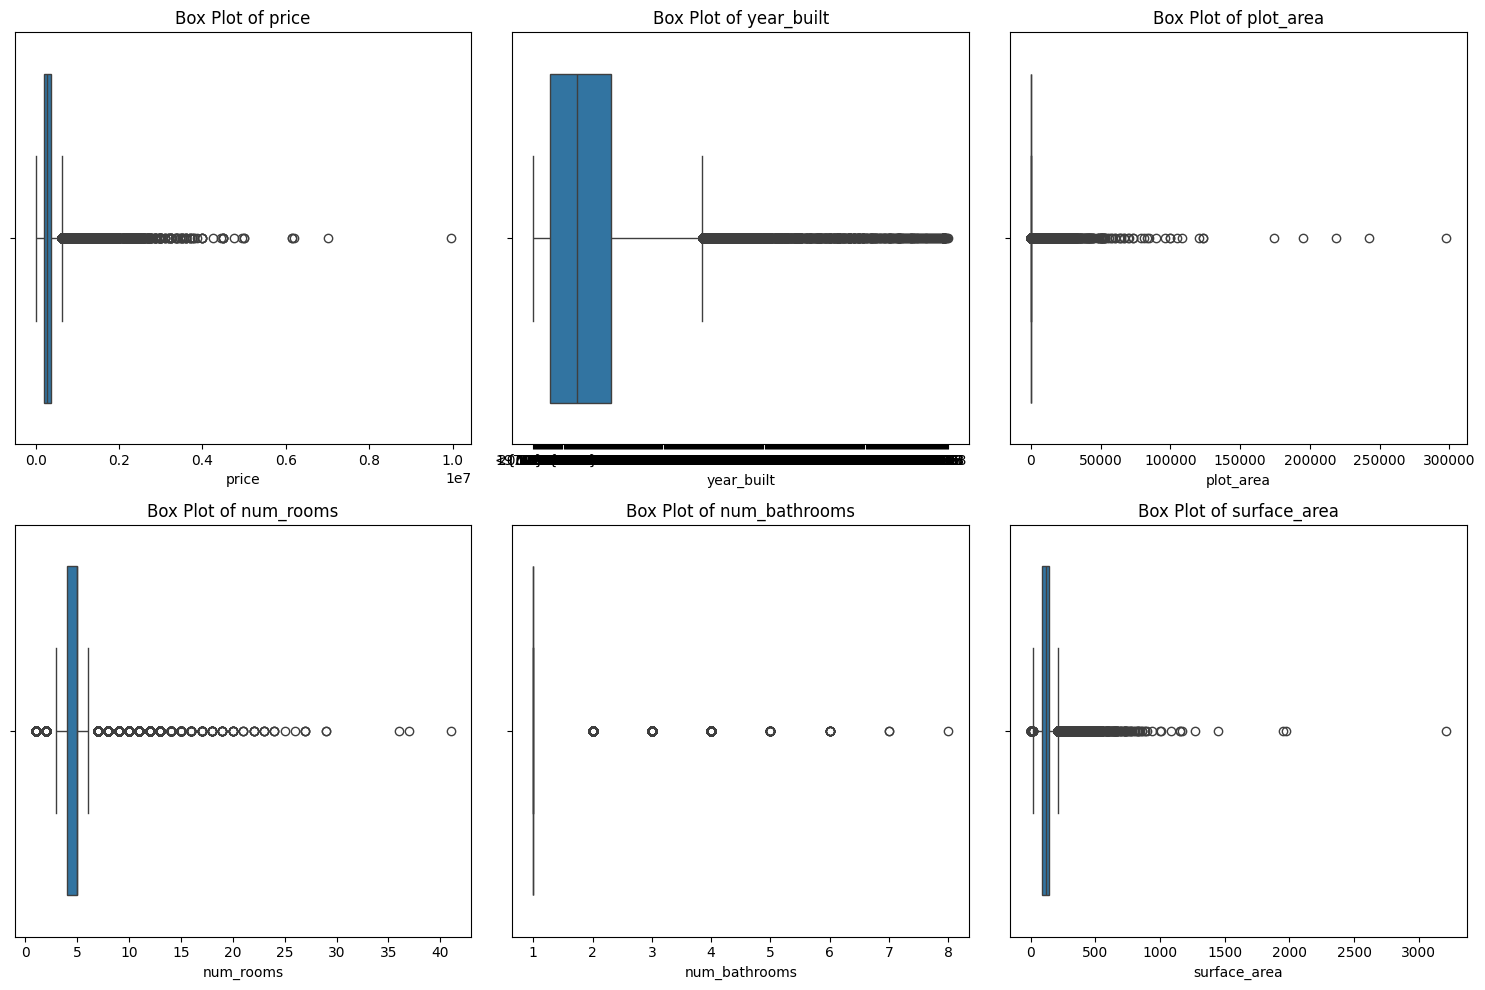

In [19]:
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(x=df[col], ax=axes[i])
    axes[i].set_title(f"Box Plot of {col}")

plt.tight_layout()
plt.show()


# ✅ **Key Observations:**  
- **Price, Plot Area, and Surface Area** exhibit significant outliers, suggesting the presence of extreme values.  
- **Year Built** has a more compact distribution, indicating most properties were built within a specific time range.  
- **Number of Rooms and Number of Bathrooms** show discrete values, as expected, but some properties may have unusually high counts.  
- **Skewness** is evident in **Price, Plot Area, and Surface Area**, which might require **log transformation or outlier treatment**.  
- The **presence of extreme values** in some features could impact machine learning models and may need careful handling.

# **5. Pairplot of Key Numerical Features**
# 🔹 Objective

The purpose of this pairplot is to visually explore relationships between key numerical variables in our dataset, particularly how they correlate with price, our target variable. This helps in understanding patterns, trends, and potential dependencies before we proceed with modeling.


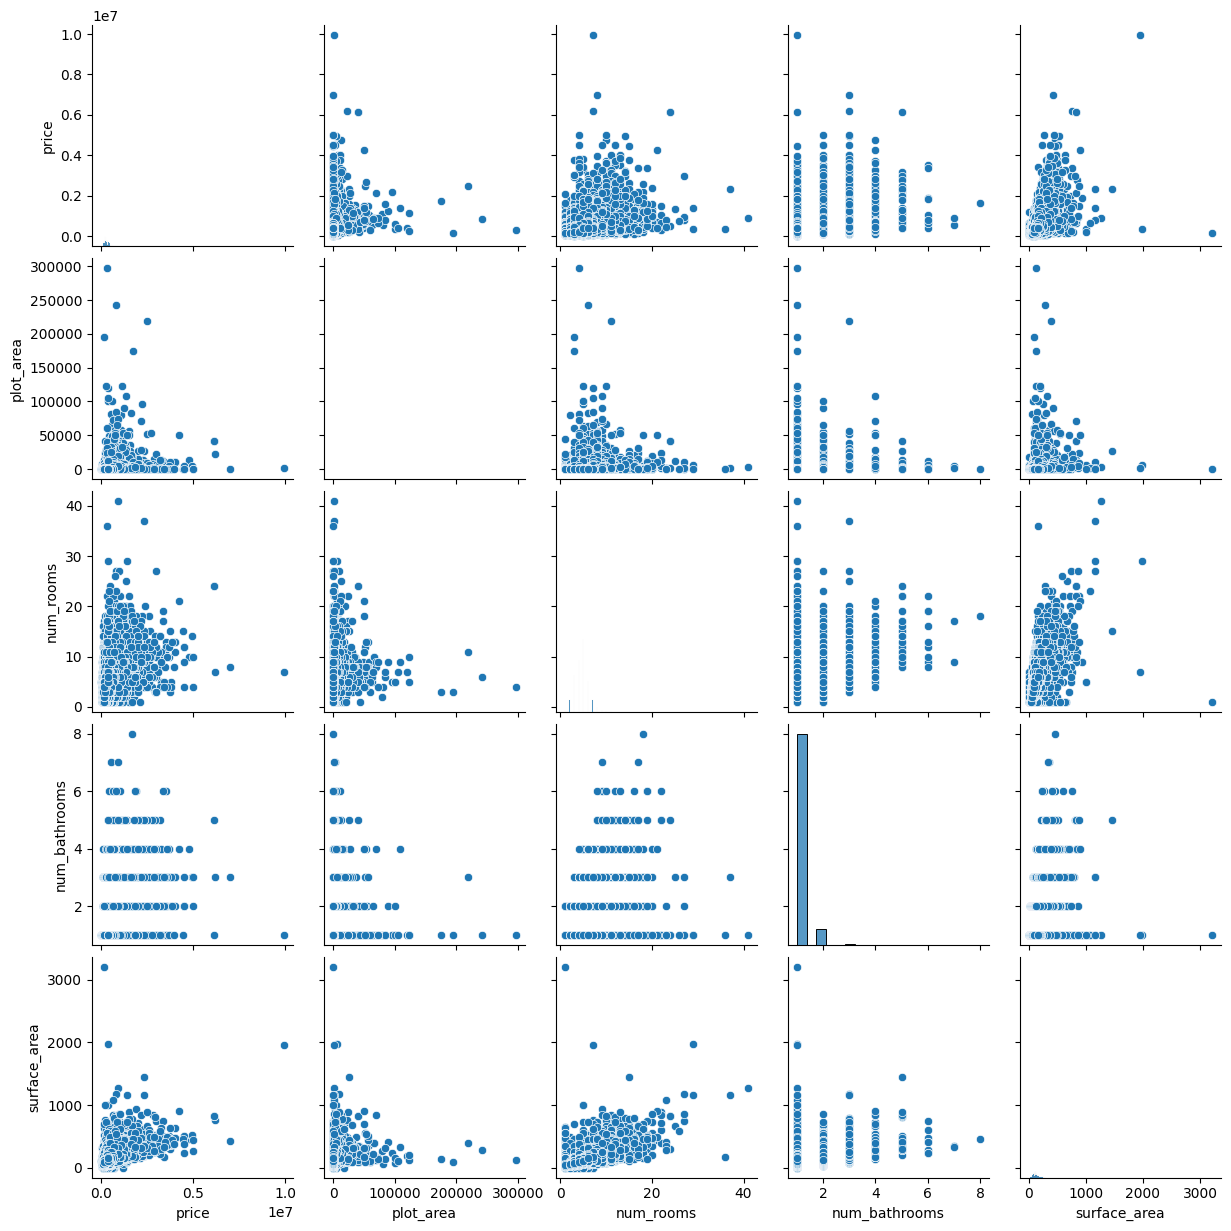

In [22]:


# Select key numerical features
num_features = ["price", "year_built", "plot_area", "num_rooms", "num_bathrooms", "surface_area"]

# Pairplot
sns.pairplot(df[num_features])
plt.show()


# ✅ **Key Observations:**  
- **Price, Plot Area, and Surface Area** exhibit significant outliers, suggesting the presence of extreme values.  
- **Year Built** has a more compact distribution, indicating most properties were built within a specific time range.  
- **Number of Rooms and Number of Bathrooms** show discrete values, as expected, but some properties may have unusually high counts.  
- **Skewness** is evident in **Price, Plot Area, and Surface Area**, which might require **log transformation or outlier treatment**.  
- The **presence of extreme values** in some features could impact machine learning models and may need careful handling.

# **6. Relationship of Price with Key Features**
# 🔹 Objective

This visualization aims to analyze how price (the target variable) is influenced by key features such as:

- **Plot Area (plot_area):** Total land size of the property.
- **Surface Area (surface_area):** Usable living space within the property.
- **Number of Rooms (num_rooms):** Total count of rooms in the property.
- **Year Built (year_built):** Age of the property.


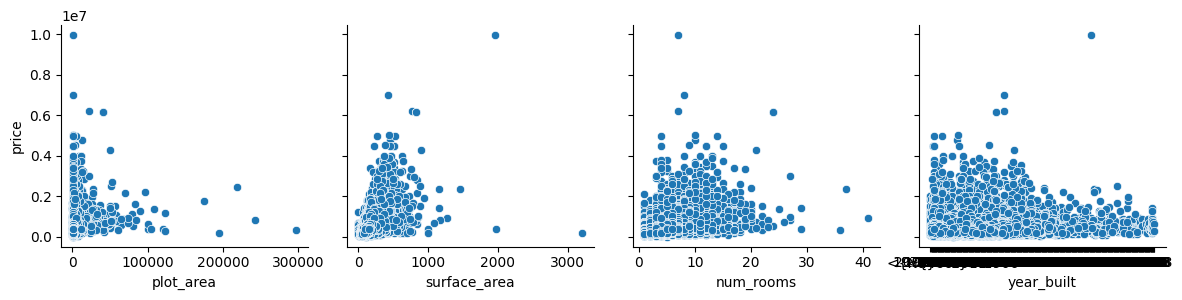

In [24]:
sns.pairplot(df, y_vars=['price'], x_vars=['plot_area', 'surface_area', 'num_rooms', 'year_built'], height=3)
plt.show()

# 🔹 Insights from the Pairplot:

1️⃣ **Strong positive correlation between surface_area & price:**  
   Larger living spaces lead to higher prices.

2️⃣ **plot_area vs. price shows some variation:**  
   Larger plots usually mean higher prices, but exceptions exist (e.g., urban areas where land is expensive).

3️⃣ **num_rooms vs. price does not show a strictly linear trend:**  
   More rooms do not always guarantee higher prices, likely due to differences in location and overall property size.

4️⃣ **year_built vs. price shows that newer homes tend to have higher prices:**  
   Older homes might be priced lower unless they are in high-demand locations or renovated.


# 7. Analysis of Target Variable (price)
# 🔹 Objective

This visualization helps analyze the distribution of property prices to understand:

- Whether the price variable is normally distributed or skewed.
- The presence of outliers (extremely high or low values).
- The overall spread and density of property prices.



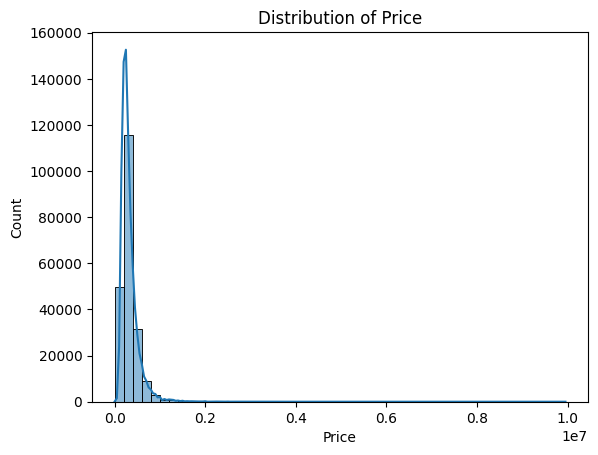

In [25]:
# Analysis of target variable (price)
sns.histplot(df['price'], kde=True, bins=50)
plt.title("Distribution of Price")
plt.xlabel("Price")
plt.show()

# 🔹 Insights from the Distribution Plot:

1️⃣ **Right-Skewed Distribution:**

- The majority of properties are priced on the lower end, while a few properties have extremely high prices.
- Indicates the presence of high-value luxury properties (outliers), which may need special handling in modeling (e.g., log transformation).

2️⃣ **High Variability in Prices:**

- There is no single dominant price range, meaning prices vary significantly across locations and property types.

3️⃣ **Need for Scaling:**

- Since prices vary greatly, models like Linear Regression might perform better if we apply log transformation or feature scaling (StandardScaler/MinMaxScaler).


# 🔹 Step 6: Feature Engineering

## 📝 Importance

We enhance the dataset by creating new features, transforming categorical values, and dropping the features that no longer contribute to our modeling process.
📌 Objective: Outlier Removal Using the IQR Method
The goal of this step is to identify and remove extreme values (outliers) from numerical columns to ensure a more robust and reliable dataset for machine learning modeling. Outliers can distort statistical analyses, skew distributions, and negatively impact model performance.

🔎 Explanation of Outlier Removal Process (Using IQR Method)
🛠 Why Remove Outliers?
Outliers are extreme values that deviate significantly from the general distribution of the dataset. If not removed, they can lead to:

Skewed model predictions (especially in regression models).
Higher variance in the dataset, making models less generalizable.
Poor feature scaling, leading to misleading relationships between variables.
📌 Methodology: Interquartile Range (IQR) for Outlier Detection
The Interquartile Range (IQR) method helps detect and remove outliers effectively. It works as follows:

1️⃣ Calculate Q1 & Q3:

Q1 (25th percentile): The value below which 25% of the data lies.
Q3 (75th percentile): The value below which 75% of the data lies.
IQR (Interquartile Range) = Q3 - Q1 (This represents the range of the middle 50% of the data).
2️⃣ Define Outlier Thresholds:

Lower Bound = Q1 - 1.5 * IQR
Upper Bound = Q3 + 1.5 * IQR
Any value outside this range is considered an outlier and is removed from the dataset.
3️⃣ Apply IQR Outlier Removal to Key Numerical Columns:

Price: High-end luxury properties with extreme prices.
Surface Area & Plot Area: Properties with excessively large or small areas.
Number of Rooms: Properties with unusually high or low room counts.


# **Remove Outliers:**  

# 🎯 **Objective:**  
The purpose of this function is to **identify and remove outliers** from a given dataset using the **Interquartile Range (IQR) method**. Removing outliers helps improve the accuracy and robustness of machine learning models.

In [20]:
# 📌 Function to remove outliers using IQR method
def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)  # First Quartile
    Q3 = df[column].quantile(0.75)  # Third Quartile
    IQR = Q3 - Q1  # Interquartile Range
    lower_bound = Q1 - 1.5 * IQR  # Lower limit for outliers
    upper_bound = Q3 + 1.5 * IQR  # Upper limit for outliers
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]


# ✅ **Key Observations:**  
- **Interquartile Range (IQR)** is calculated as the difference between the 75th percentile (**Q3**) and the 25th percentile (**Q1**).  
- Any value **below** `Q1 - 1.5 * IQR` or **above** `Q3 + 1.5 * IQR` is considered an **outlier**.  
- The function filters out these extreme values, retaining only the observations **within the valid range**.  
- This method is useful for **handling skewed distributions** and datasets with extreme values that might impact model performance.  
- While effective for many cases, **IQR may not be suitable for normally distributed data with natural variance**—alternative techniques like **Z-score** or **Winsorization** may be considered.  

# **Data Preprocessing: Cleaning & Transformation**


# 🎯 Objective:  
This code performs **data preprocessing** to clean and transform key features for further analysis and modeling. The main tasks include **converting postal codes**, **removing outliers**, and **handling date columns**.



In [18]:
# Convert postal codes to numeric
df['postal_code'] = df['postal_code'].astype(str).str[:2]
df = df[df['postal_code'].str.isnumeric()]
df['postal_code'] = df['postal_code'].astype(int)


In [ ]:
# 📌 List of numerical columns for outlier removal
num_cols_for_outliers = ["price", "surface_area", "plot_area", "num_rooms"]
for col in num_cols_for_outliers:
    df = remove_outliers(df, col)

In [ ]:
# 📌 Convert date columns
df['publication_date'] = pd.to_datetime(df['publication_date'])
df['signing_date'] = pd.to_datetime(df['signing_date'])
df['listing_year'] = df['publication_date'].dt.year
df['construction_year'] = df['signing_date'].dt.year
df.drop(columns=['publication_date', 'signing_date', 'energy_label', 'agency_hash'], inplace=True)


# ✅ **Key Observations:**  
- **Postal Code Processing:**  
  - Extracts the **first two digits** of the postal code as a numeric representation.  
  - Filters out **non-numeric** postal codes before converting them into integers.  

- **Outlier Removal:**  
  - Applies the **IQR method** to remove extreme values from key numerical features:  
    - `price`, `surface_area`, `plot_area`, and `num_rooms`.  
  - Helps in improving the **distribution and stability** of data for modeling.  

- **Date Column Transformation:**  
  - Converts `publication_date` and `signing_date` to **datetime format**.  
  - Extracts **year** values as `listing_year` and `construction_year` for simplified analysis.  
  - Drops unnecessary columns: `publication_date`, `signing_date`, `energy_label`, and `agency_hash` to reduce redundancy.  

- **Impact on Data Quality:**  
  - **Enhances feature consistency** by standardizing postal codes and dates.  
  - **Removes extreme values** that could negatively impact model performance.  
  - **Prepares cleaned and structured data** for further feature engineering or predictive modeling.  









# **Categorical Encoding: One-Hot Encoding**

# 🎯 Objective:  
This step applies **One-Hot Encoding (OHE)** to convert categorical variables into a numerical format, making them suitable for machine learning models.


In [19]:
# 📌 One-Hot Encoding for categorical column
ohe = OneHotEncoder(drop="first", sparse_output=False)
df["category"] = ohe.fit_transform(df[["category"]]).astype(int)


# ✅ **Key Observations:**  
- The `category` column is transformed using **One-Hot Encoding**, where:  
  - The first category is **dropped** to prevent multicollinearity (`drop="first"`).  
  - The encoding is applied **without sparse output** (`sparse_output=False`) for easier handling in DataFrames.  
- Converts categorical values into **binary (0/1) format**, allowing models to interpret them effectively.  
- The transformed values are cast to **integer type (`int`)** to optimize memory usage.  
- Helps in ensuring **compatibility with machine learning algorithms** that require numerical inputs.  









In [20]:
df.isnull().sum()

id                   0
postal_code          0
price                0
description          0
property_type        0
category             0
year_built           0
garden               0
plot_area            0
num_rooms            0
num_bathrooms        0
surface_area         0
listing_year         0
construction_year    0
dtype: int64

# Hugging Face based Feature Extraction

# 📌 **Objective:** Convert text descriptions into numeric embeddings.


In [ ]:
# 📌 Load tokenizer and model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_name = "sentence-transformers/all-MiniLM-L6-v2"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name).to(device)
model.eval()
# 📌 Function to extract text embeddings
def extract_features_in_batches(text_series, batch_size=32):
    embeddings = []
    for i in tqdm(range(0, len(text_series), batch_size)):
        batch_texts = text_series[i:i + batch_size].astype(str).tolist()
        inputs = tokenizer(batch_texts, padding=True, truncation=True, return_tensors="pt").to(device)
        with torch.no_grad():
            outputs = model(**inputs)
        batch_embeddings = outputs.last_hidden_state[:, 0, :].cpu().numpy()
        embeddings.append(batch_embeddings)
    return np.vstack(embeddings)
# 📌 Apply feature extraction
description_embeddings = extract_features_in_batches(df['description'])
property_type_embeddings = extract_features_in_batches(df['property_type'])


  0%|                                                                              | 9/6590 [01:10<13:07:18,  7.18s/it]

In [ ]:
# 📌 Feature Scaling before PCA
scaler = StandardScaler()
description_embeddings_scaled = scaler.fit_transform(description_embeddings)
property_type_embeddings_scaled = scaler.fit_transform(property_type_embeddings)

# ✅ **Results:**
# - **Text features** converted to numerical vectors.


#                    Step 7️⃣ Dimensionality Reduction (PCA)


# 📌 **Objective:** Reduce the size of  Text embeddings.


In [24]:
# 📌 Apply PCA after scaling
pca = PCA(n_components=45)
description_pca = pca.fit_transform(description_embeddings_scaled)
property_type_pca = pca.fit_transform(property_type_embeddings_scaled)

In [ ]:
# 📌 Ensure columns exist before dropping
columns_to_drop = ['description', 'property_type']
df = df.drop(columns=[col for col in columns_to_drop if col in df.columns], errors='ignore')


In [ ]:
# 📌 Merge PCA results with dataset
df_final = pd.concat([df, pd.DataFrame(description_pca), pd.DataFrame(property_type_pca)], axis=1)


In [ ]:
# 📌 Display final dataset shape
print("Display final dataset shape:", df_final.shape)


#                Step 8️⃣. Saving the Cleaned Dataset for Modeling


In [25]:
df_final.to_csv("/kaggle/working/Cleaned_Housing_Data.csv", index=False)
print("Final cleaned dataset saved as 'Cleaned_Housing_Data.csv'.")
print("EDA & Feature Engineering Completed Successfully!")


Final cleaned dataset saved as 'Cleaned_Housing_Data.csv'.
EDA & Feature Engineering Completed Successfully!


# ✅ **Final Dataset is Ready for Machine Learning Modeling!**